In [7]:
import os
from typing import Tuple, Final, Literal

from IPython import display
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.graph import StateGraph
from langgraph.store.postgres import PostgresStore

load_dotenv()

DB_URL = os.getenv("DB_URL")

with PostgresStore.from_conn_string(DB_URL) as store:
    # 1、创建长期记忆存储的表格
    store.setup()
    # 2、构建永久记忆数据
    # 2.1 构建命名空间
    USERS_NS: Final[Tuple[str]] = ("users",)
    PREFERENCES_KEY: Final[str] = "preferences"

    namespace1 = (*USERS_NS, "Alice")
    namespace2 = (*USERS_NS, "Bob")
    namespace3 = (*USERS_NS, "Black")

    value1 = {
        "course": "计算机组成原理",
        "sports": "跑步",
        "food": "紫光园奶皮子酸奶"
    }

    value2 = {
        "course": "数字电路与模拟电路",
        "sports": "跑步",
        "food": "奶皮子糖葫芦"
    }

    value3 = {
        "course": "计算机组成原理",
        "sports": "羽毛球",
        "food": "紫光园奶皮子酸奶"
    }

    # 3、写入永久记忆数据
    store.put(namespace1, PREFERENCES_KEY, value1)
    store.put(namespace2, PREFERENCES_KEY, value2)
    store.put(namespace3, PREFERENCES_KEY, value3)

    for item in store.search(USERS_NS):
        print(item)

Item(namespace=['users', 'Black'], key='preferences', value={'food': '紫光园奶皮子酸奶', 'course': '计算机组成原理', 'sports': '羽毛球'}, created_at='2026-08-03T06:38:15.674661+08:00', updated_at='2026-08-03T08:57:00.061493+08:00', score=None)
Item(namespace=['users', 'Bob'], key='preferences', value={'food': '奶皮子糖葫芦', 'course': '数字电路与模拟电路', 'sports': '跑步'}, created_at='2026-08-03T06:38:15.632712+08:00', updated_at='2026-08-03T08:57:00.009783+08:00', score=None)
Item(namespace=['users', 'Alice'], key='preferences', value={'food': '紫光园奶皮子酸奶', 'course': '计算机组成原理', 'sports': '跑步'}, created_at='2026-08-03T06:38:15.583154+08:00', updated_at='2026-08-03T08:56:59.961451+08:00', score=None)


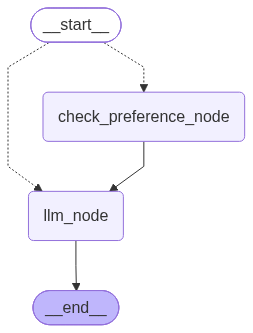

2026-08-03 09:25:21.125 | INFO     | __main__:router:31 - 需要从长期记忆中读取用户偏好
2026-08-03 09:25:21.173 | INFO     | __main__:check_preference_node:51 - 长期记忆中保证的Alice的偏好数据是{'food': '紫光园奶皮子酸奶', 'course': '计算机组成原理', 'sports': '跑步'}
2026-08-03 09:25:23.479 | INFO     | __main__:router:33 - 用户偏好已经存在，不需要查询


{'messages': [SystemMessage(content='请根据用户的偏好解决用户的需求', additional_kwargs={}, response_metadata={}, id='5fff8618-db24-4953-9893-50b84a9f45fb'), HumanMessage(content="这是用户偏好：{'food': '紫光园奶皮子酸奶', 'course': '计算机组成原理', 'sports': '跑步'}\n, 这是用户的需求:我有点无聊，和我聊聊天吧", additional_kwargs={}, response_metadata={}, id='a427b242-a824-4b04-90ed-ecf1b135a031'), AIMessage(content='哈哈，无聊的时候最适合做点自己喜欢的事啦！既然你喜欢跑步，不如现在出门跑个5公里？跑完回来挖一勺紫光园奶皮子酸奶，那感觉绝对爽。要是懒得动，咱们也可以聊聊计算机组成原理——比如“指令周期”和“流水线”哪个更像你跑步时的呼吸节奏？😄 你更想先聊哪个？', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 56, 'total_tokens': 137, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 56}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': 'ffd8925d-6300-49d9-8cb2-fddb37afe1c1', 'finish_reason': 'stop',

In [12]:
from langgraph.constants import START, END
from langgraph.graph.message import MessagesState
from loguru import logger
from langgraph.runtime import Runtime
from langchain_deepseek import ChatDeepSeek

# 获取大模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


# 1、声明全局状态
class OverAllState(MessagesState):
    username: str
    user_input: str
    output: str
    preferences: dict[str, str]


# 2、声明节点
# 2.1 路由函数，如果状态中没有用户偏好 则从长期记忆中查询，否则直接执行大模型节点
def router(state: OverAllState) -> Literal["check_preference_node", "llm_node"]:
    # 条件判断，使用get方法（查看状态中是否包含长期记忆）
    if not state.get("preferences"):
        logger.info("需要从长期记忆中读取用户偏好")
        return "check_preference_node"
    logger.info("用户偏好已经存在，不需要查询")
    return "llm_node"


# 2.2 检查长期记忆节点
def check_preference_node(state: OverAllState, runtime: Runtime) -> OverAllState:
    # 1、拼接命名空间
    username = state["username"]
    namespace = (*USERS_NS, username)
    key = PREFERENCES_KEY
    # 2、获取长期记忆数据
    run_store = runtime.store
    run_item = run_store.get(namespace, key)

    if not run_item:
        logger.warning("长期记忆中没有{}的偏好数据", username)
        return {}

    logger.info("长期记忆中保证的{}的偏好数据是{}", username, run_item.value)
    # 从长期记忆中读取到用户偏好，将其设置在状态中
    return {
        "preferences": item.value
    }


def llm_node(state: OverAllState) -> OverAllState:
    # 检查是否存在长期记忆
    preference = state.get("preferences", {})
    user_intput = state["user_input"]
    human_prompt = f"这是用户偏好：{preference}\n, 这是用户的需求:{user_intput}"
    system_prompt = "请根据用户的偏好解决用户的需求"

    # 如果state 状态里面messages为空，则将system_prompt加入messages，否则使用状态里面的 messages
    # : list[SystemMessage | HumanMessage | AIMessage | ToolMessage] 表示 messages的类型
    messages: list[SystemMessage | HumanMessage | AIMessage | ToolMessage] = [
        SystemMessage(content=system_prompt)] if not state.get("messages", []) else state["messages"]
    # 执行大模型
    model_response = model.invoke(messages + [HumanMessage(content=human_prompt)])
    output = model_response.content

    return {
        "messages": messages + [HumanMessage(content=human_prompt), model_response],
        "output": output
    }


# 3、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("check_preference_node", check_preference_node)
builder.add_node("llm_node", llm_node)

builder.add_conditional_edges(START, router, path_map=["check_preference_node", "llm_node"])
builder.add_edge("check_preference_node", "llm_node")
builder.add_edge("llm_node", END)

# 4、构建长期记忆（store）和短期记忆（checkpoint）
with PostgresStore.from_conn_string(DB_URL) as store, PostgresSaver.from_conn_string(DB_URL) as checkpointer:
    # 幂等操作 多次执行不会重新创建表格，不会删除表格中的数据
    checkpointer.setup()
    graph = builder.compile(checkpointer=checkpointer, store=store)

    display.display(graph)

    config = {
        "configurable": {"thread_id": "779"}
    }
    # config 是为了使用短期记忆
    res = graph.invoke({"username": "Alice", "user_input": "我有点无聊，和我聊聊天吧"}, config=config)
    print('=' * 50)
    print(res)

    res1 = graph.invoke({"username": "Alice", "user_input": "推荐一下酸奶"}, config=config)

    print('=' * 50)
    print(res1)